In [1]:
from pathlib import Path

import cv2
import imutils
import imageio

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tqdm.auto import tqdm
tqdm.pandas()

In [20]:
images = [
    "organized_15G2021-1826_P2_ac7563a9647b7a4d",
    "organized_2017.06254_S3_fde63f0b0eed4b60",
    "organized_2019.02184_S1_bac955ea325378a4",
    "organized_2020.04013_P1_8c430bcc0c5a1b59",
    "organized_ABAURA5676_P4_7209f30f5a787536",
    "organized_ABAURA5667_P1_b65c91f3f7307c39",
    "organized_ABAURA4928_S1_ed8e3393b98a0803",
    "organized_ABAURA57210_P1_74fd3bdda28e9f50",
    "organized_CD387804_P1_1ad4ee377c8d268a",
    "organized_FR15ABOM110721013_P1_7c47133be5617baa"
]
imgs_root = "../data/crops/light/organized/"

In [ ]:
def white_balance(image, q=99):
    brightness = np.max(image, axis=2)
    
    threshold = np.percentile(brightness, q)
    white_pixels = image[brightness >= threshold]
    
    mean_white = np.mean(white_pixels, axis=0)
    
    scale = 255.0 / mean_white
    
    balanced = image.astype(np.float32) * scale
    
    balanced = np.clip(balanced, 0, 255).astype(np.uint8)
    return balanced

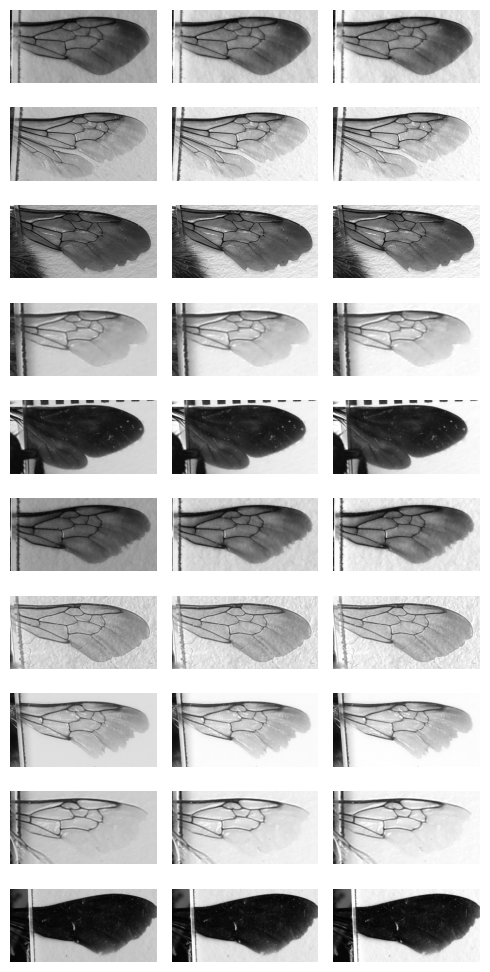

In [34]:
fig, axes = plt.subplots(len(images),3,figsize=(5,10))

for i, img in enumerate(images):
    image = cv2.imread(f"{imgs_root}{img}.jpg")

    corrected95 = white_balance(image, 95)
    corrected99 = white_balance(image, 99)

    axes[i,0].imshow(image)
    axes[i,1].imshow(corrected99)
    axes[i,2].imshow(corrected95)
    axes[i,0].axis('off')
    axes[i,1].axis('off')
    axes[i,2].axis('off')

plt.tight_layout()
plt.show()

In [1]:
for i in [
    "WB1_23_140.jpg",
    "WB1_23_0005_1.jpg",
    "WB1_23_0007_1.jpg",
    "WB1_23_0091_1.jpg",
    "WB1_23_0036_1.jpg",
    "WB1_23_0065_2.jpg",
    "WB1_23_0065_3.jpg"
]:
    print(i)

WB1_23_140.jpg
WB1_23_0005_1.jpg
WB1_23_0007_1.jpg
WB1_23_0091_1.jpg
WB1_23_0036_1.jpg
WB1_23_0065_2.jpg
WB1_23_0065_3.jpg


In [9]:
PROJECT_ROOT = Path.cwd().parent
MANIFEST_DIR = PROJECT_ROOT / 'data' / 'manifests'
OUTPUT_DIR = PROJECT_ROOT / 'out' / 'crop'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Racine du projet : {PROJECT_ROOT}')

Racine du projet : /Users/superbg/Documents/Jules/IEES/idmybee


## Autocrop

In [15]:
manifest = pd.read_csv(MANIFEST_DIR / 'manifest.csv')

usable_pairs = manifest[manifest['statut'] == 'paire_exploitable'].copy()
sample_indices = np.random.choice(len(usable_pairs), size=min(10, len(usable_pairs)), replace=False)

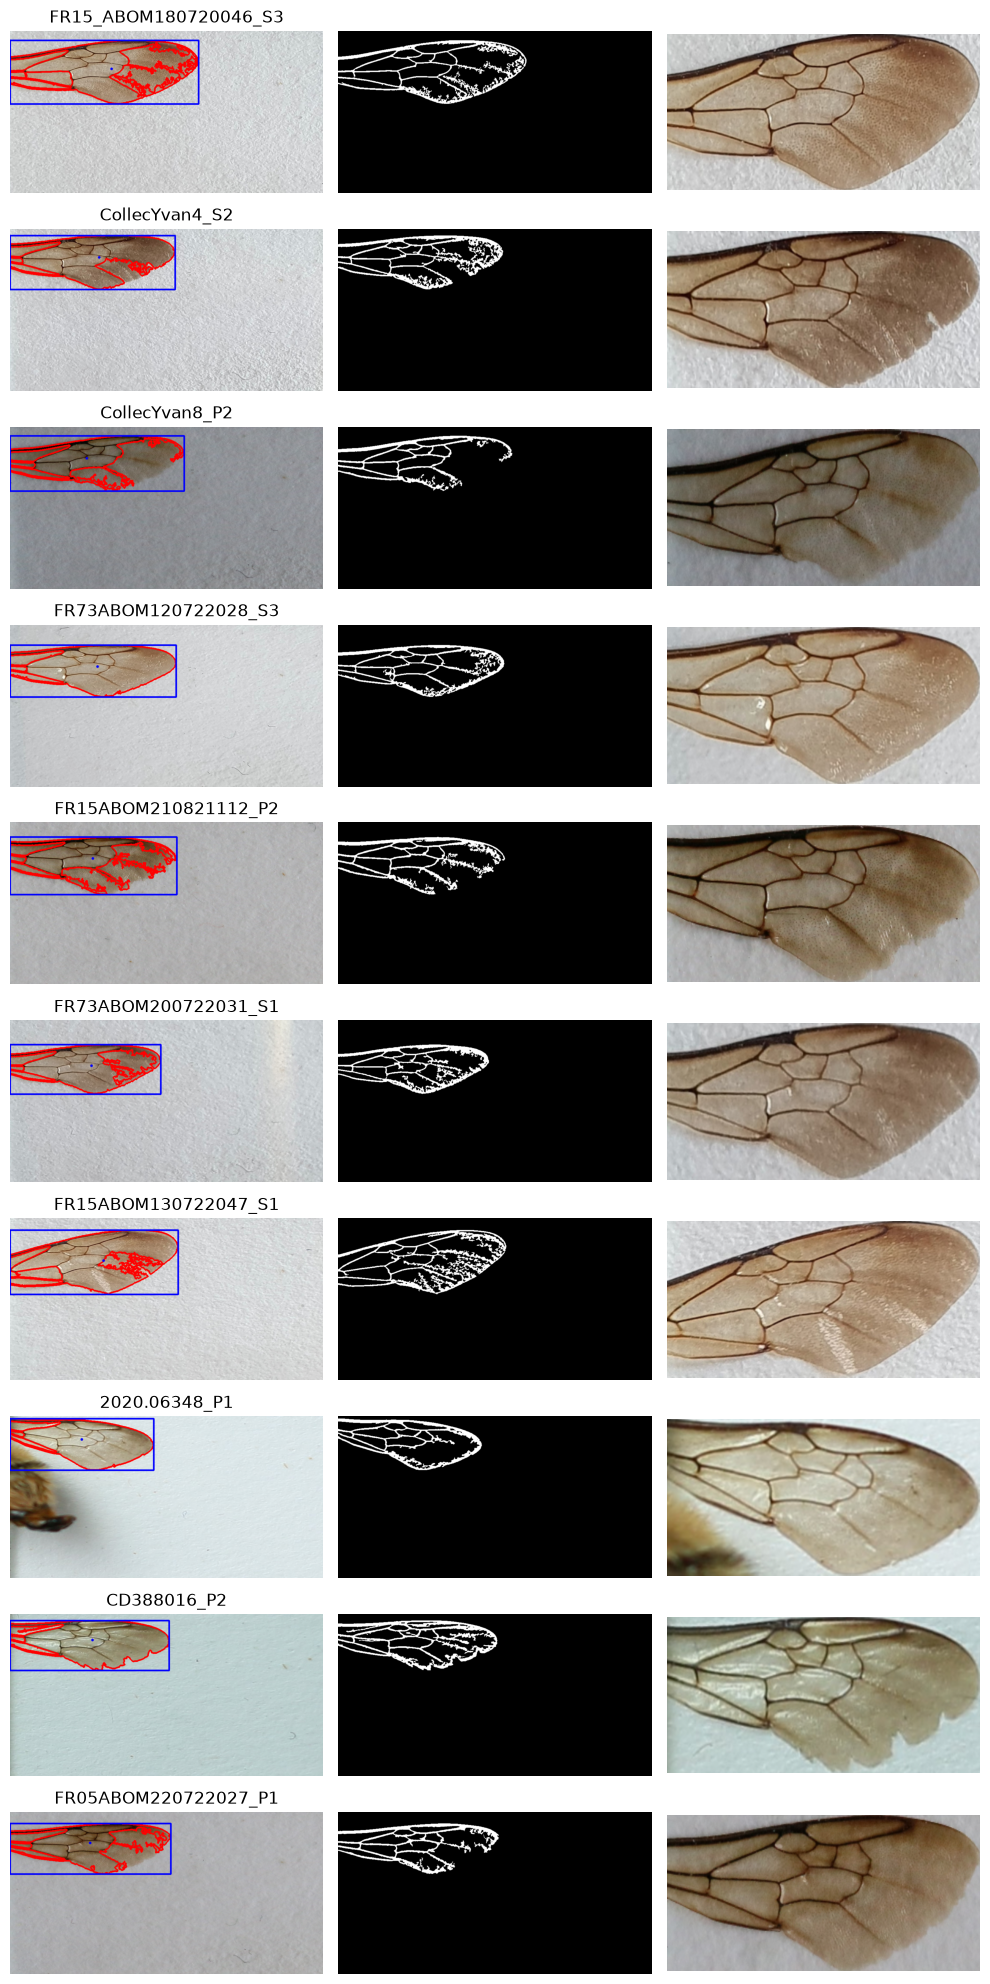

In [18]:
fig, axes = plt.subplots(len(sample_indices), 3, figsize=(10, 2*len(sample_indices)))
if len(sample_indices) == 1:
    axes = axes.reshape(1, -1)

for row, idx in enumerate(sample_indices):
    crop_path = PROJECT_ROOT / usable_pairs.iloc[idx]['chemin_crop_large']
    image = cv2.imread(str(crop_path), cv2.IMREAD_COLOR)

    name = crop_path.stem
    
    image = cv2.resize(image, (960, 540))
    image = image[56:, 24:]
    
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 31, 2)
    
    # -------- CONTOURS --------
    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    c = max(cnts, key=cv2.contourArea)
    x1, y1, w1, h1 = cv2.boundingRect(c)

    # -- CONNECTED COMPONENTS --
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(thresh,
        connectivity=8, ltype=cv2.CV_32S)

    largest_label = np.argmax(stats[1:, cv2.CC_STAT_AREA]) + 1
    component_mask = (labels == largest_label).astype(np.uint8) * 255

    x2, y2, w2, h2 = stats[largest_label, :-1]
    (cX, cY) = centroids[largest_label]

    # ---------- PLOT ----------
    output = image.copy()
    # countours bbox
    cv2.drawContours(output, [c], -1, (0, 0, 255), 3)
    cv2.rectangle(output, (x1, y1), (x1 + w1, y1 + h1), (0, 255, 0), 3)
    # connected bbox
    cv2.rectangle(output, (x2, y2), (x2 + w2, y2 + h2), (255, 0, 0), 3)
    cv2.circle(output, (int(cX), int(cY)), 4, (255, 0, 0), -1)

    # cropped wing
    wing = cv2.cvtColor(image.copy()[y2:y2+h2,x2:x2+w2], cv2.COLOR_BGR2RGB)
    wing = cv2.resize(wing, (512, 256))

    axes[row, 0].imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    axes[row, 1].imshow(cv2.cvtColor(component_mask, cv2.COLOR_BGR2RGB))
    axes[row, 2].imshow(wing)

    axes[row, 0].set_title(f'{name}')
    axes[row, 0].axis('off')
    axes[row, 1].axis('off')
    axes[row, 2].axis('off')

    imageio.imwrite(f'{OUTPUT_DIR}/{name}.png', wing)



plt.tight_layout()
plt.show()